**Introduction**

Churn prediction is highly important in machine learning and business analytics for several reasons:Predicting customer churn helps businesses identify and retain valuable customers, reducing revenue loss; Acquiring new customers is often more expensive than retaining existing ones. Churn prediction allows companies to focus resources on retention efforts; Analyzing churn data provides insights into customer behavior and preferences, helping to improve products and services; Predictive models enable personalized marketing and engagement strategies to prevent churn; Companies that can effectively predict and mitigate churn gain a competitive edge by maintaining a loyal customer base; Churn prediction fosters data-driven decision-making, aiding in strategic planning and resource allocation; Reducing churn enhances overall customer satisfaction and loyalty; Maintaining a stable customer base is crucial for sustainable business growth.

This machine learning project contains the code which predicts churning using logistic regression model:

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.model_selection import GridSearchCV

C:\Users\Professor\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


**1. Data Understanding: loading and exploring dataset**

In [3]:
df = pd.read_csv('train.csv')
display(df.head())


,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
1,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
2,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,no
3,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no
4,MA,121,area_code_510,no,yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,no


In [4]:
print('**The shape or dimension of the data is as follows:** \n',df.shape,'\n') #Checking the shape of the data
print('**checking missing values from each column:** \n',df.isnull().sum())  #chacking missing values
print('**checking NaN values from each column:** \n',df.isna().sum()) #chacking NaN values

**The shape or dimension of the data is as follows:** 
 (4250, 20) 

**checking missing values from each column:** 
 state                            0
account_length                   0
area_code                        0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge               0
total_intl_minutes               0
total_intl_calls                 0
total_intl_charge                0
number_customer_service_calls    0
churn                            0
dtype: int64
**checking NaN values from each column:** 
 state                            0
account_length                   0
area_code                        0
international_plan   

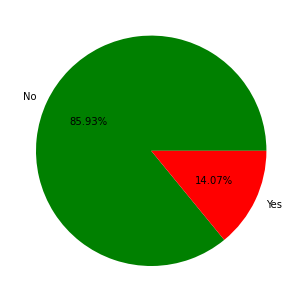

{'no': 3652, 'yes': 598}


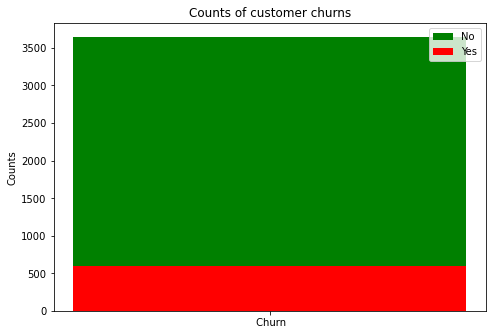

In [5]:
#Checking class imbalance

#Piechart
yes_no_count= df['churn'].value_counts()
churn_score=[]

for churn in yes_no_count:
    churn_score.append(churn)

fig =plt.figure()
ax=fig.add_axes([0,0,1,1])
churning=['No','Yes']
colors=['green','red']
ax.pie(churn_score, labels=churning, colors=colors, autopct='%1.2f%%')
plt.show()

#Bar Graph

approval_counts= (df['churn'].value_counts()).to_dict()
print(approval_counts)
fig=plt.figure()
ax=fig.add_axes([0,0,1,1])
ax.bar([' Churn'],approval_counts['no'], color='g', label='No')
ax.bar([' Churn'],approval_counts['yes'], color='r', label='Yes')
ax.set_ylabel('Counts')
ax.set_title('Counts of customer churns')
ax.legend()
plt.show()


**2. Data Preprocessing: Prepare the data modelling by handling missing values, encoding catagorical variables, scaling numerical features and handling class imbalance**

In [6]:
#Encoding 'previous_application.csv'
encoded_df= df.copy()

# Encoding different columns (With label encoder)
label_enc=['state','area_code']
label_encoder = LabelEncoder()

for column in label_enc:
    encoded_value= label_encoder.fit_transform(encoded_df[column])
    encoded_df[column]= encoded_value

#Encoding different columns (with ordinal encoder)
all_mapping={'international_plan':{'no':0,'yes':1},'voice_mail_plan':{'no':0,'yes':1},'churn':{'no':0,'yes':1}}

for column in all_mapping:
    mapping= all_mapping[column]
    ordinal_encoder= OrdinalEncoder(categories =[list(mapping.keys())])
    encoded_df[column]= ordinal_encoder.fit_transform(encoded_df[[column]])
    
display(encoded_df.head())  

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,35,107,1,0.0,1.0,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0.0
1,31,137,1,0.0,0.0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0.0
2,35,84,0,1.0,0.0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0.0
3,36,75,1,1.0,0.0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0.0
4,19,121,2,0.0,1.0,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0.0


**3. Feature Selection: Selecting the most relevant features from the dataset that will be used as input variables**

In [7]:
#create our output data (single list) and feature as a (matrix/ lists of list)

#single array ouput data, i.e convert churn output data into numeric, no as 1 and yes as 0
churn_output_data =np.array(list(encoded_df['churn']))

numeric_churn= []

for churn in churn_output_data:
    numeric_churn.append(churn)
    
#features as a matrix/ lists of list

features=encoded_df.columns
f=[]
for feature in features:
    lst= np.array((encoded_df[feature]))
    f.append(lst)

feature_data= ((np.array(f)).transpose())[:,0:19]  #selecting all rows except the last one
print(feature_data)


[[ 35.   107.     1.   ...   3.     3.7    1.  ]
 [ 31.   137.     1.   ...   5.     3.29   0.  ]
 [ 35.    84.     0.   ...   7.     1.78   2.  ]
 ...
 [ 27.    75.     0.   ...   7.     1.86   1.  ]
 [ 11.    50.     0.   ...   5.     2.67   2.  ]
 [ 46.    86.     1.   ...  16.     2.51   0.  ]]


In [8]:
#PERFORM FEATURE SELECTION

k=4
selector = SelectKBest(score_func= chi2, k=k)
new_feature= selector.fit_transform(feature_data, numeric_churn)

selected_indices = selector.get_support(indices=True)
selected_features = [features[i] for i in selected_indices]

print('The selected indices indices is/are: ', selected_indices)
print('The selected features is/are: ',selected_features)  


The selected indices indices is/are:  [5 6 8 9]
The selected features is/are:  ['number_vmail_messages', 'total_day_minutes', 'total_day_charge', 'total_eve_minutes']


**4. Model Training: Split the dataset into training and testing sets**

number_vmail_messages: -0.031153533688291112
total_day_minutes: 0.01276161517528978
total_day_charge: -0.0031327923875473546
total_eve_minutes: 0.004984667728789354


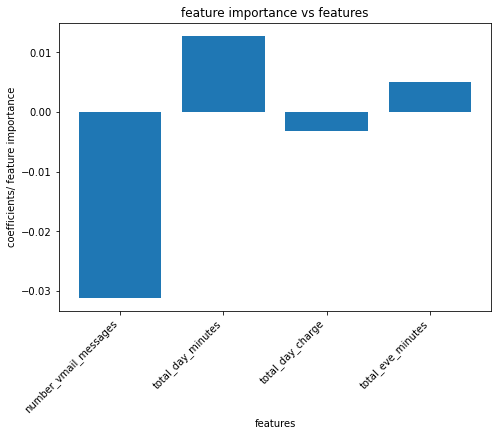

interpretation: 

1. Positive Coefficient: This suggests that the feature has a positive association with the likelihood of the positive outcome
2. Negative Coefficient: This suggests that the feature has a negative association with the likelihood of the negative outcome
3. Magnitude of the Coefficient: Indicates the strength of the relationship between the feature and the outcome


In [9]:

X= np.array(encoded_df[selected_features])
y= numeric_churn

logReg= LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)
logReg.fit(X_train,y_train)

coefficients=logReg.coef_[0]  #Getting the coefficients or feature importance
coefficients_names_zip= list(zip(selected_features,coefficients)) #Associate coefficients with feature names                                                                                                 

feature_list=[]
coefficient_list=[]

for feature, coefficient in coefficients_names_zip:
    print(f'{feature}: {coefficient}')
    feature_list.append(feature)
    coefficient_list.append(coefficient)
    
fig=plt.figure()
ax=fig.add_axes([0,0,1,1])
ax.bar(feature_list,coefficient_list)
ax.set_xlabel('features')
ax.set_ylabel('coefficients/ feature importance')
ax.set_title('feature importance vs features')

plt.xticks(rotation='45',ha='right')
plt.show()

print('interpretation: \n')
print('1. Positive Coefficient: This suggests that the feature has a positive association with the likelihood of the positive outcome')
print('2. Negative Coefficient: This suggests that the feature has a negative association with the likelihood of the negative outcome')
print('3. Magnitude of the Coefficient: Indicates the strength of the relationship between the feature and the outcome')



**5. Model Evaluation: Evaluating the performance of the trained model using appropriate evaluation metrics, i.e accuracy, precision and f1 score**

In [10]:
# Using  Accuracy Score the evaluate the performance of the model
y_predict= logReg.predict(X_test)
accuracy= accuracy_score(y_test,y_predict)
precision= precision_score(y_test,y_predict)
f1= f1_score(y_test,y_predict)

print('The accuracy of the model is: ',accuracy)
print('The precision of the model is: ',precision)
print('The f1_score of the model is: ',f1)

The accuracy of the model is:  0.8541176470588235
The precision of the model is:  1.0
The f1_score of the model is:  0.07462686567164178


**6. Model Optimization: Fine tune the model by adjusting hyperparameters to enhance its predictive performance**

In [11]:
#definining the hyper parameter grid for logistic regression

param_grid = {
    'penalty':['l2'],
     'C':[0.1,1,10]
}

#Performing grid search with cross-validation
grid_search = GridSearchCV(estimator= logReg, param_grid= param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print('Best score: ',  grid_search.best_score_)

best_model= grid_search.best_estimator_
best_accuracy = best_model.score(X_test, y_test)
print("Test Set Accuracy: ",best_accuracy,'\n')

print('if the accuracy score does not change then in our case,' )
print('The selected hyperparameter grid for optimization does not include the optimal combination of hyperparametrs, i.e L1 or l1')

Best Hyperparameters: {'C': 0.1, 'penalty': 'l2'}
Best score:  0.8670588235294119
Test Set Accuracy:  0.8541176470588235 

if the accuracy score does not change then in our case,
The selected hyperparameter grid for optimization does not include the optimal combination of hyperparametrs, i.e L1 or l1


**7. Model Deployment: Deploying the optimised model to make predictions on new, unseen data.**

In [12]:
df2= pd.read_csv('test.csv')

encoded_df2= df2.copy()


# Encoding different columns (With label encoder)
label_enc=['state','area_code']
label_encoder = LabelEncoder()

for column in label_enc:
    encoded_value= label_encoder.fit_transform(encoded_df2[column])
    encoded_df2[column]= encoded_value

#Encoding different columns (with ordinal encoder)
all_mapping={'international_plan':{'no':0,'yes':1},'voice_mail_plan':{'no':0,'yes':1}}

for column in all_mapping:
    mapping= all_mapping[column]
    ordinal_encoder= OrdinalEncoder(categories =[list(mapping.keys())])
    encoded_df2[column]= ordinal_encoder.fit_transform(encoded_df2[[column]])
    
display(encoded_df2.head())  

,id,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
0,1,16,128,1,0.0,1.0,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,2,1,118,2,1.0,0.0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0
2,3,12,62,1,0.0,0.0,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4
3,4,46,93,2,0.0,0.0,0,190.7,114,32.42,218.2,111,18.55,129.6,121,5.83,8.1,3,2.19,3
4,5,29,174,1,0.0,0.0,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3


In [13]:
unseen_X= np.array(encoded_df2[selected_features])

new_predictions= best_model.predict(unseen_X)
target_response= (pd.DataFrame(new_predictions).value_counts()).to_dict()

for response in target_response:
    if  response==(0.0,):
        print(f'There are {target_response[response]} predicted clients that are less likely to churn')
    else:
        print(f'There are {target_response[response]} predicted clients that most likely to churn')

There are 747 predicted clients that are less likely to churn
There are 3 predicted clients that most likely to churn


In [3]:
import tensorflow as tf

ModuleNotFoundError: No module named 'tensorflow'